In [1]:
import tensorflow as tf # abni el model , a7ml el data ,train
#Load Dataset
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "Training",
    validation_split=0.2,#80% training
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Training",
    validation_split=0.2, # 20% from training
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [2]:
#Dataset Summary
print("Number of classes:", len(class_names))
print("Classes:", class_names)

train_batches = tf.data.experimental.cardinality(train_ds).numpy()
#4480/32 = 140 batches of training
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
#1120/32 = 35 batches of validation
test_batches = tf.data.experimental.cardinality(test_ds).numpy()
#1600/32=50 batches of test
print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)

Number of classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train batches: 140
Validation batches: 35
Test batches: 50


{'glioma': 1140, 'meningioma': 1125, 'notumor': 1100, 'pituitary': 1115}


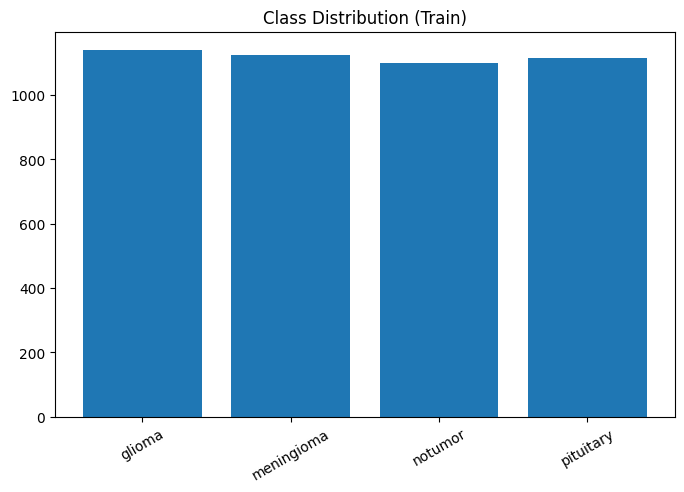

In [3]:
#Class Distribution Plot
import matplotlib.pyplot as plt

class_counts = {name: 0 for name in class_names}

for images, labels in train_ds:
    for label in labels.numpy():
        class_counts[class_names[label]] += 1
print(class_counts)

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values()) # key: name classes
plt.title("Class Distribution (Train)")
plt.xticks(rotation=30)
plt.show()

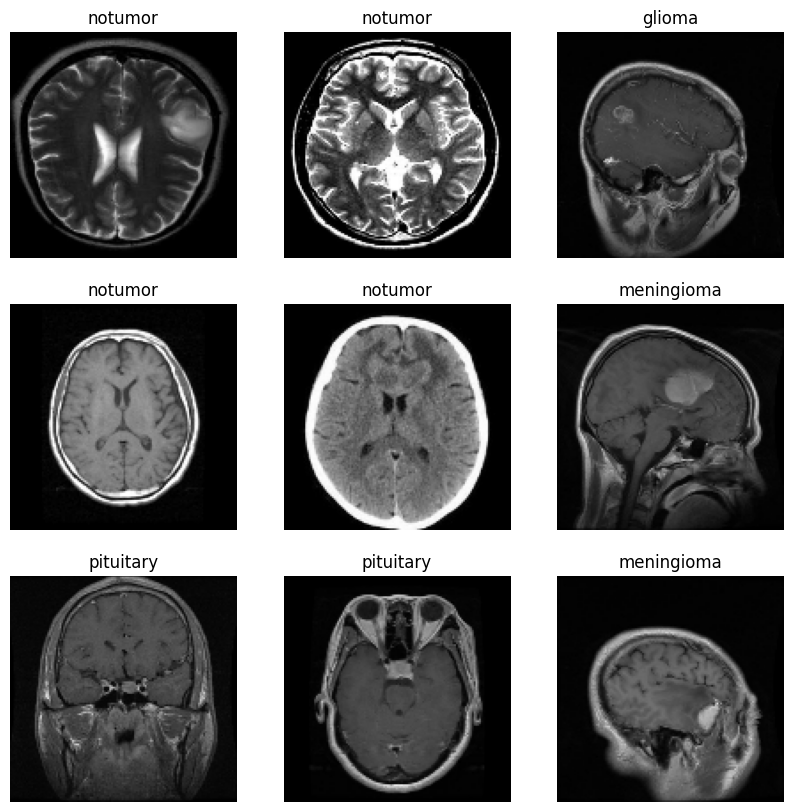

In [4]:
#Sample Images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [5]:
#Duplicate Check
import os

all_files = []
for root, dirs, files in os.walk("Training"):
    for file in files:
        all_files.append(file)

print("Total files:", len(all_files))
print("Unique files:", len(set(all_files)))

Total files: 5600
Unique files: 5600


In [6]:
#Sample Count Check
train_count = sum([images.shape[0] for images, labels in train_ds])
#(batch_size (32), 128, 128, 3) bya5od index 0 lkol el batches el heya 3dd el sowar b3dha ygma3hom 3la ba3d ytal3 3dd el sowar f el train 4480
val_count = sum([images.shape[0] for images, labels in val_ds])
test_count = sum([images.shape[0] for images, labels in test_ds])

print("Train samples:", train_count)
print("Validation samples:", val_count)
print("Test samples:", test_count)

Train samples: 4480
Validation samples: 1120
Test samples: 1600


* Since the dataset consists of standard image files loaded via image_dataset_from_directory, there are no missing tabular values. We checked for duplicated filenames and found all files are unique. No extreme outliers in pixel intensities exist as all images were standard RGB arrays and properly rescaled to the [0, 1] range."

In [7]:
#Normalization : faster 0 to 1
normalization_layer = tf.keras.layers.Rescaling(1./255)
# 1/255

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)) #tuple
# ba3ml normaliza ll x image bs m4 ha3ml ll label el howa 0, 1 ,2,3
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)


val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
#lw 3mlt shuffle(mix) 3la test kol mra image hattl3li b label 4akl

In [9]:
from tensorflow.keras import layers, models
# layers di tabkat el 4abka el 3asabeya as
# dense , conv2d , dropout , flatten

input_shape = (128, 128, 3)
num_classes = len(class_names)

ffnn_model = models.Sequential([
    layers.Input(shape=input_shape),


    layers.Flatten(),



    layers.Dense(512, activation='relu'),

    layers.Dropout(0.3),


    layers.Dense(256, activation='relu'), # feature compression
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

In [10]:
ffnn_model.compile( # hatt3lm ezay, hat8lat ezay,hatkaim ezay
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# by7mini mn el overfitting
early_stop_ffnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,#by3ml 5 epochs b3d a5er ta7sin w b3dha yo2af 34an el ta7ason momkn yb2a motkat3 m4 sabet
    restore_best_weights=True # hayrag3 afdal epoch fiha afdal accuracy w validation loss
)

In [12]:
import time

start = time.time() #beygib el wa2t el7ali

history_ffnn = ffnn_model.fit( # train 3la el sowar
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_ffnn]
)

end = time.time()

ffnn_training_time = end - start # el wa2t el koli ll train b el seconds
ffnn_epoch_time = ffnn_training_time / len(history_ffnn.history['loss'])
# wa2t train el model kolo b el seconds / 3dd el epochs el f3lan et3almt

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.4685 - loss: 2.4811 - val_accuracy: 0.6643 - val_loss: 0.8861
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.5754 - loss: 0.9750 - val_accuracy: 0.7125 - val_loss: 0.7892
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.5741 - loss: 0.9467 - val_accuracy: 0.5964 - val_loss: 0.9421
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.6174 - loss: 0.8652 - val_accuracy: 0.7652 - val_loss: 0.6011
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.6100 - loss: 0.8309 - val_accuracy: 0.7464 - val_loss: 0.6492
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.6239 - loss: 0.8138 - val_accuracy: 0.7491 - val_loss: 0.6680
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.6337 - loss: 0.7962 - val_accuracy: 0.7455 - val_loss: 0.6206
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.6310 - loss: 0.8113 - 

In [13]:
#Convolutional Neural Network
# Input → Conv2D → Pooling → Flatten → Dense → Output

cnn_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

In [14]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',#34an 3ndi multi class classif
    metrics=['accuracy']
)

In [15]:
# prevent overfitting
early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # 5 epochs
    restore_best_weights=True
)

In [16]:
start = time.time()

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds, # test during training
    epochs=20,
    callbacks=[early_stop_cnn]
)

end = time.time()

cnn_training_time = end - start
cnn_epoch_time = cnn_training_time / len(history_cnn.history['loss'])

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.6846 - loss: 0.7790 - val_accuracy: 0.8268 - val_loss: 0.4755
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8080 - loss: 0.4884 - val_accuracy: 0.8652 - val_loss: 0.3699
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8594 - loss: 0.3577 - val_accuracy: 0.8929 - val_loss: 0.2878
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8975 - loss: 0.2687 - val_accuracy: 0.9027 - val_loss: 0.2669
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9217 - loss: 0.2091 - val_accuracy: 0.9161 - val_loss: 0.2241
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9382 - loss: 0.1612 - val_accuracy: 0.9295 - val_loss: 0.2135
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9596 - loss: 0.1139 - val_accuracy: 0.9375 - val_loss: 0.1942
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9719 - loss: 0.0821 - 

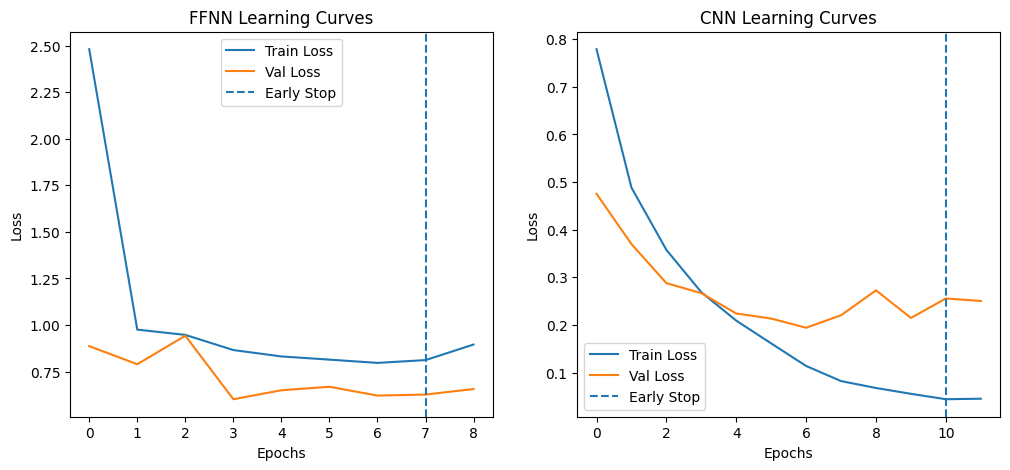

In [17]:
# FFNN history
ffnn_loss = history_ffnn.history['loss']
ffnn_val_loss = history_ffnn.history['val_loss']
ffnn_stop_epoch = early_stop_ffnn.stopped_epoch


# CNN history
cnn_loss = history_cnn.history['loss']
cnn_val_loss = history_cnn.history['val_loss']
cnn_stop_epoch = early_stop_cnn.stopped_epoch

epochs_ffnn = range(len(ffnn_loss)) # 0 to 19
#  list fiha kol loss
epochs_cnn = range(len(cnn_loss))

plt.figure(figsize=(12,5)) # width , height

# FFNN
plt.subplot(1,2,1) # 1 row, 2 columns, first graph


plt.plot(epochs_ffnn, ffnn_loss, label='Train Loss')
plt.plot(epochs_ffnn, ffnn_val_loss, label='Val Loss')
plt.axvline(x=ffnn_stop_epoch-1, linestyle='--', label='Early Stop')
plt.title("FFNN Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# CNN
plt.subplot(1,2,2)
plt.plot(epochs_cnn, cnn_loss, label='Train Loss') # model byt3lm ad eh 3la el training
plt.plot(epochs_cnn, cnn_val_loss, label='Val Loss') # hal el model by3rf y4t8l 3la sowar gdida

plt.axvline(x=cnn_stop_epoch-1, linestyle='--', label='Early Stop')
plt.title("CNN Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [18]:
ffnn_stop_epoch = early_stop_ffnn.stopped_epoch
cnn_stop_epoch = early_stop_cnn.stopped_epoch

print("FFNN stopped at epoch:", ffnn_stop_epoch) # 0 mafi4 stopping 7asl
print("CNN stopped at epoch:", cnn_stop_epoch)


FFNN stopped at epoch: 8
CNN stopped at epoch: 11


### Overfitting Analysis
The FFNN model showed signs of overfitting, as the training loss decreased while the validation loss remained higher and less stable.
In contrast, the CNN model demonstrated better generalization, with a smaller gap between training and validation loss, indicating improved performance on unseen data.

### Regularization (Dropout)
Dropout was applied as a regularization technique to reduce overfitting in both models.
By randomly deactivating a portion of neurons during training, dropout prevents the model from relying too heavily on specific features.
This helped improve validation performance and enhanced the model’s generalization ability.

Without dropout, the model tends to memorize the training data

#### L1/L2 regularization was not applied in this project. Instead, dropout was used as an effective regularization technique.

In [19]:
# Evaluate models on test set
ffnn_test_loss, ffnn_test_acc = ffnn_model.evaluate(test_ds)
# hangrb 3la test data model el fnn
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_ds)

print("FFNN Test Accuracy:", ffnn_test_acc) # precentage el sa7
print("CNN Test Accuracy:", cnn_test_acc)

#F1-Score for FFNN
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds: # bnlf 3la kol batch f el test
    preds = ffnn_model.predict(images)
    preds = preds.argmax(axis=1)

    y_true.extend(labels.numpy()) # store right answers in y true
    y_pred.extend(preds) # store predictions of model in y pred

print("FFNN Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

#F1-Score for CNN
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = cnn_model.predict(images)
    preds = preds.argmax(axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("CNN Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6525 - loss: 0.8977
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8831 - loss: 0.9671
FFNN Test Accuracy: 0.6524999737739563
CNN Test Accuracy: 0.8831250071525574
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━

#### In medical imaging tasks like Brain Tumor Classification, F1-Score is crucial alongside Accuracy because False Negatives (missing a tumor) are highly critical. Therefore, we evaluated both metrics.
* In addition to accuracy, F1-score was used to evaluate model performance. The CNN model achieved higher F1-scores across most classes, indicating better overall performance.

* Although the dataset is balanced, F1-score was also used as an additional evaluation metric for a more comprehensive performance analysis.

In [20]:
# Results
print("FFNN Total Training Time:", round(ffnn_training_time, 2), "seconds") # (ffnn_training_time = end - start)
print("FFNN Avg Epoch Time:", round(ffnn_epoch_time, 2), "seconds")
#ffnn_epoch_time = ffnn_training_time / number_of_epochs
print("\nCNN Total Training Time:", round(cnn_training_time, 2), "seconds")
print("CNN Avg Epoch Time:", round(cnn_epoch_time, 2), "seconds")

FFNN Total Training Time: 101.42 seconds
FFNN Avg Epoch Time: 11.27 seconds

CNN Total Training Time: 129.23 seconds
CNN Avg Epoch Time: 10.77 seconds


In [21]:
#speed = عدد الصور / الوقت

# Count Test Samples
num_samples = sum(len(images) for images, labels in test_ds)
# num images in each batch

# FFNN Inference Speed
start = time.time()

ffnn_model.predict(test_ds)
# inference
end = time.time()

ffnn_inference_time = end - start
ffnn_speed = num_samples / ffnn_inference_time

# CNN Inference Speed
start = time.time()

cnn_model.predict(test_ds)

end = time.time()

cnn_inference_time = end - start
cnn_speed = num_samples / cnn_inference_time

# Results

print("FFNN Inference Time:", round(ffnn_inference_time, 2), "seconds")
print("FFNN Speed:", round(ffnn_speed, 2), "samples/sec")

print("\nCNN Inference Time:", round(cnn_inference_time, 2), "seconds")
print("CNN Speed:", round(cnn_speed, 2), "samples/sec")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
FFNN Inference Time: 0.34 seconds
FFNN Speed: 4680.18 samples/sec

CNN Inference Time: 1.04 seconds
CNN Speed: 1540.42 samples/sec


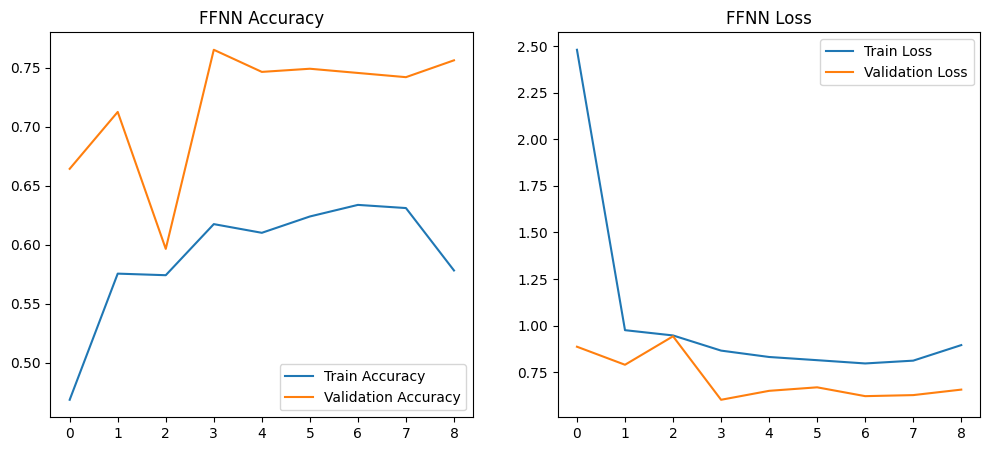

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_ffnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_ffnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('FFNN Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ffnn.history['loss'], label='Train Loss')
plt.plot(history_ffnn.history['val_loss'], label='Validation Loss')
plt.title('FFNN Loss')
plt.legend()

plt.show()

* The FFNN learning curves indicate a noticeable gap between training and validation performance. Training accuracy steadily increased across epochs, while validation accuracy remained lower and showed fluctuations instead of consistent improvement.

* Training loss continuously decreased, whereas validation loss stayed higher and slightly increased during later epochs. This suggests that the model learned the training data effectively but had limited generalization ability on unseen validation samples, indicating overfitting.

  Model  Accuracy      Loss  Training Time (sec)  Epoch Time (sec)  \
0  FFNN  0.652500  0.897659           101.422090         11.269121   
1   CNN  0.883125  0.967126           129.230126         10.769177   

   Inference Speed (samples/sec)  
0                    4680.179790  
1                    1540.422934  


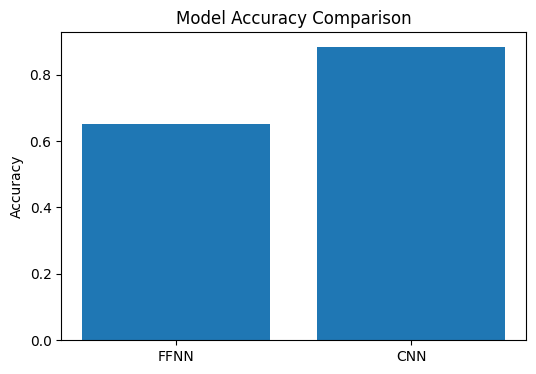

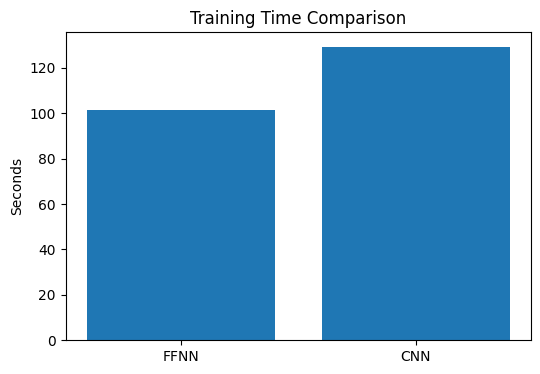

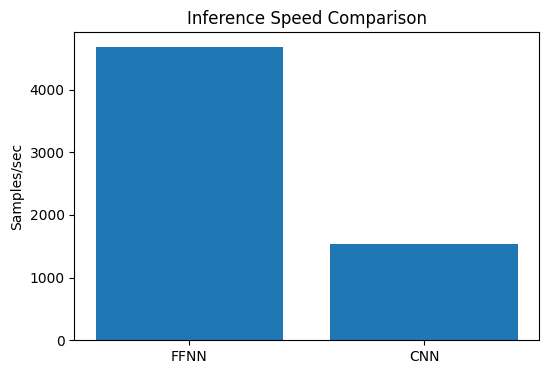

In [23]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["FFNN", "CNN"],
    "Accuracy": [ffnn_test_acc, cnn_test_acc],
    "Loss": [ffnn_test_loss, cnn_test_loss],
    "Training Time (sec)": [ffnn_training_time, cnn_training_time],
    "Epoch Time (sec)": [ffnn_epoch_time, cnn_epoch_time],
    "Inference Speed (samples/sec)": [ffnn_speed, cnn_speed]
})

print(results)

# Accuracy Comparison

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Training Time Comparison

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Training Time (sec)"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

# Inference Speed Comparison

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Inference Speed (samples/sec)"])
plt.title("Inference Speed Comparison")
plt.ylabel("Samples/sec")
plt.show()

### Comparison Summary

The CNN model achieved higher accuracy and better generalization compared to FFNN. 
Although CNN required slightly more training time, it provided better performance on unseen data. 
FFNN was faster but suffered from overfitting and lower accuracy.

## Optimization Experiments for CNN

### Experiment 1: High Learning Rate

In [24]:
#unstable training and lower validation performance,
experiment1_cnn = models.Sequential([ # bengahz el model
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

experiment1_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment1 = experiment1_cnn.fit( # badrb el model
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.2520 - loss: 2.2629 - val_accuracy: 0.2545 - val_loss: 1.3860
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.2525 - loss: 1.3868 - val_accuracy: 0.2321 - val_loss: 1.3878
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.2471 - loss: 1.3873 - val_accuracy: 0.2321 - val_loss: 1.3890
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.2493 - loss: 1.3870 - val_accuracy: 0.2321 - val_loss: 1.3885
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.2482 - loss: 1.3874 - val_accuracy: 0.2321 - val_loss: 1.3873


* Using a high learning rate (0.01) resulted in unstable training and lower validation performance, indicating that a smaller learning rate is more suitable.

### Experiment 2: Without Dropout

In [25]:
#overfitting
experiment2_cnn = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

experiment2_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment2 = experiment2_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.6949 - loss: 0.7468 - val_accuracy: 0.8607 - val_loss: 0.4320
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8828 - loss: 0.3274 - val_accuracy: 0.9000 - val_loss: 0.2878
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9324 - loss: 0.1828 - val_accuracy: 0.9089 - val_loss: 0.2688
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9674 - loss: 0.0943 - val_accuracy: 0.9286 - val_loss: 0.2428
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9882 - loss: 0.0392 - val_accuracy: 0.9196 - val_loss: 0.3066


* Removing dropout led to higher training accuracy but worse validation performance, indicating overfitting.

### Experiment 3: Lower Learning Rate

In [26]:
#more stable training and improved validation performance.
experiment3_cnn = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

experiment3_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment3 = experiment3_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.6623 - loss: 0.8364 - val_accuracy: 0.8205 - val_loss: 0.5373
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8127 - loss: 0.5076 - val_accuracy: 0.8116 - val_loss: 0.4766
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8621 - loss: 0.3888 - val_accuracy: 0.8420 - val_loss: 0.4166
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8958 - loss: 0.3081 - val_accuracy: 0.8446 - val_loss: 0.4007
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9105 - loss: 0.2605 - val_accuracy: 0.8759 - val_loss: 0.3599


* Using a smaller learning rate (0.0001) resulted in more stable training and improved validation performance. 

* The model was able to converge more smoothly compared to a higher learning rate, leading to better generalization on unseen data.

### Experiment 4: Data Augmentation

In [27]:
 # bn7awl n3alm el= model en el waram nafso 7ata lw el sora malet maslan aw 3akztha
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

experiment4_cnn = models.Sequential([
    layers.Input(shape=(128,128,3)),
    
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

experiment4_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_experiment4 = experiment4_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.6382 - loss: 0.8758 - val_accuracy: 0.6750 - val_loss: 0.7677
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7643 - loss: 0.6121 - val_accuracy: 0.8393 - val_loss: 0.4599
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8011 - loss: 0.5166 - val_accuracy: 0.7679 - val_loss: 0.6233
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8237 - loss: 0.4560 - val_accuracy: 0.8054 - val_loss: 0.5483
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8444 - loss: 0.4094 - val_accuracy: 0.8500 - val_loss: 0.4306
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8493 - loss: 0.3952 - val_accuracy: 0.8777 - val_loss: 0.3315
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8672 - loss: 0.3439 - val_accuracy: 0.8964 - val_loss: 0.2974
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8768 - loss: 0.3206 - 

* Data augmentation techniques such as random flipping and rotation were applied to increase data diversity and reduce overfitting. This helped improve the model's generalization on unseen data.

### CNN Experiments — Learning Curves Comparison

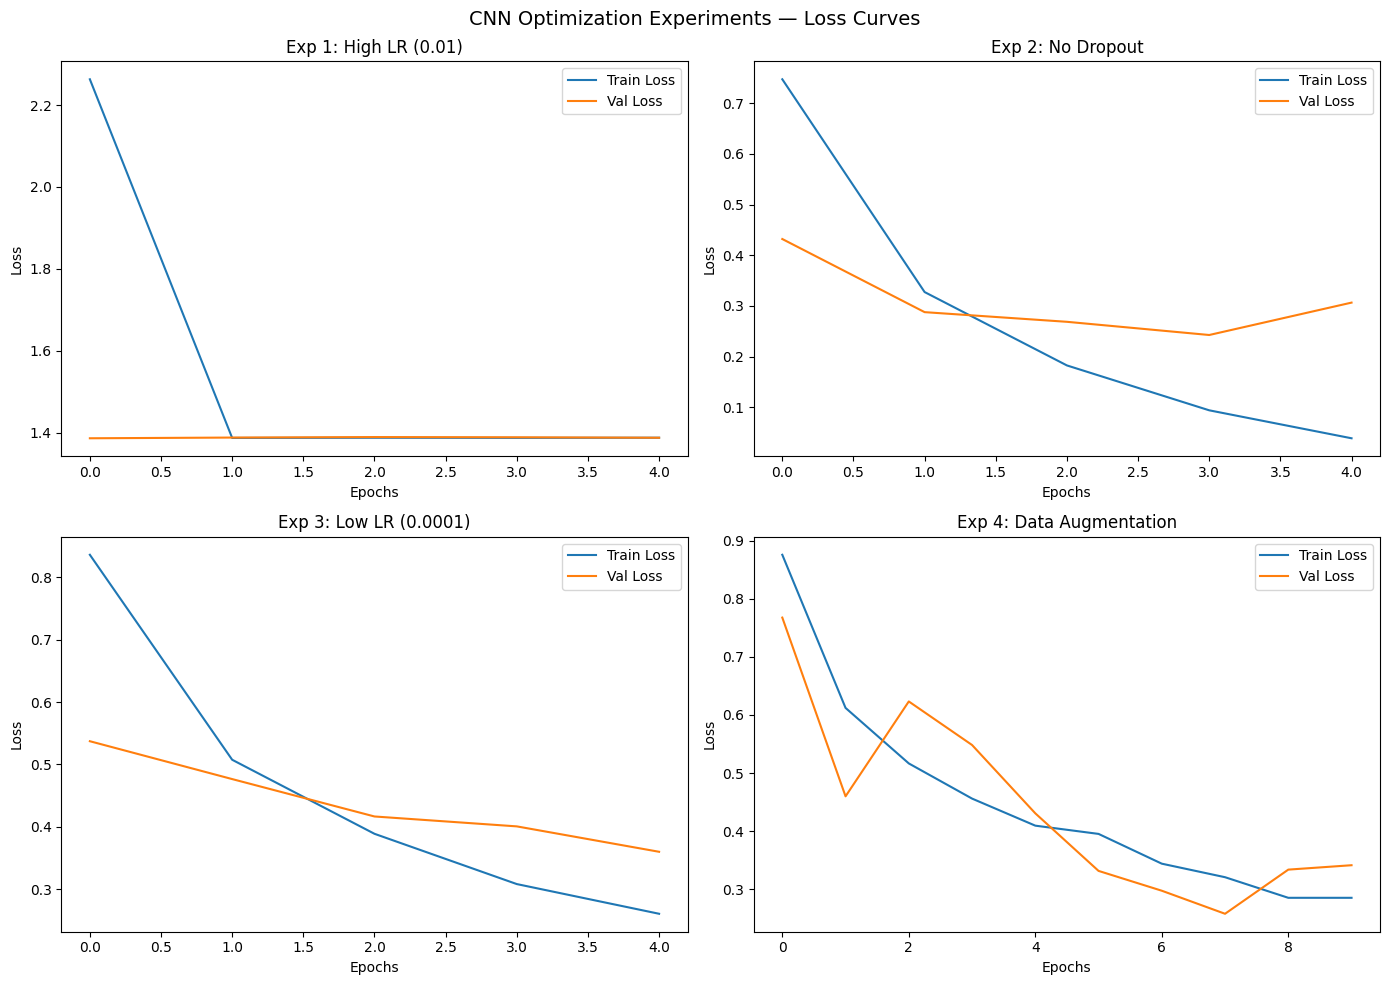

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # bn7awlhom l[axes[0], axes[1], axes[2], axes[3]]
# 34an n3raf nlef 3alehom
experiments = [
    (history_experiment1, "Exp 1: High LR (0.01)"),
    (history_experiment2, "Exp 2: No Dropout"),
    (history_experiment3, "Exp 3: Low LR (0.0001)"),
    (history_experiment4, "Exp 4: Data Augmentation"),
]

for i, (hist, title) in enumerate(experiments):
    axes[i].plot(hist.history['loss'], label='Train Loss')
    axes[i].plot(hist.history['val_loss'], label='Val Loss')
    axes[i].set_title(title)
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Loss")
    axes[i].legend()

plt.suptitle("CNN Optimization Experiments — Loss Curves", fontsize=14)
plt.tight_layout()
plt.show()

### CNN Experiments — Validation Accuracy Comparison

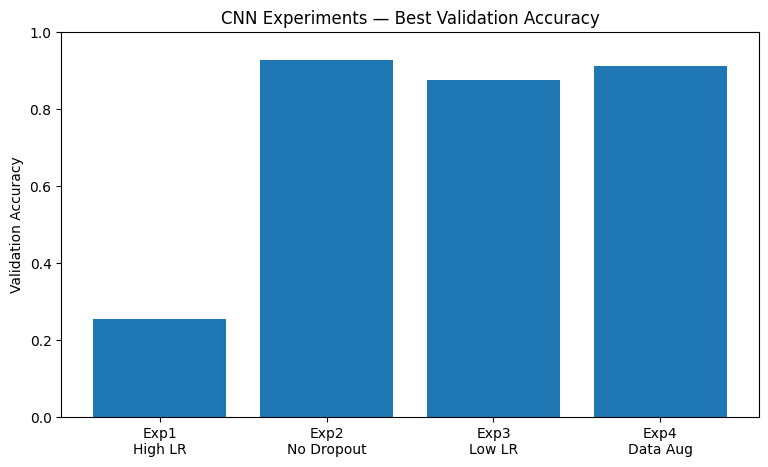

In [29]:
val_accs = [
    max(history_experiment1.history['val_accuracy']),
    max(history_experiment2.history['val_accuracy']),
    max(history_experiment3.history['val_accuracy']),
    max(history_experiment4.history['val_accuracy']),
] #hagib best accuracy l kol model wasal liha

exp_labels = [
    "Exp1\nHigh LR",
    "Exp2\nNo Dropout",
    "Exp3\nLow LR",
    "Exp4\nData Aug",
]

plt.figure(figsize=(9, 5))
plt.bar(exp_labels, val_accs)
plt.title("CNN Experiments — Best Validation Accuracy")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1) # 5ali me7war el y mn 0 to 1
plt.show()

### These experiments demonstrate how hyperparameter choices and architecture
### decisions significantly impact CNN performance on image classification tasks

## Optimization Experiments for FFNN

### Experiment 1: High Learning Rate

In [30]:
experiment1_ffnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

experiment1_ffnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ffnn_exp1 = experiment1_ffnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.3712 - loss: 14.9895 - val_accuracy: 0.4875 - val_loss: 1.1444
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.4951 - loss: 1.1474 - val_accuracy: 0.5518 - val_loss: 1.0101
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.5529 - loss: 1.0194 - val_accuracy: 0.6795 - val_loss: 0.7630
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.5853 - loss: 0.9686 - val_accuracy: 0.6812 - val_loss: 0.7932
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.6098 - loss: 0.9238 - val_accuracy: 0.6687 - val_loss: 0.7768


* Using a high learning rate (0.01) caused unstable training for the FFNN.
* Validation loss fluctuated heavily and did not converge, confirming that


### Experiment 2: Without Dropout

In [31]:
experiment2_ffnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

experiment2_ffnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ffnn_exp2 = experiment2_ffnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.5777 - loss: 1.9527 - val_accuracy: 0.7188 - val_loss: 0.6748
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.7069 - loss: 0.7567 - val_accuracy: 0.7098 - val_loss: 0.6782
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.7772 - loss: 0.5806 - val_accuracy: 0.7982 - val_loss: 0.5677
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8165 - loss: 0.4857 - val_accuracy: 0.7357 - val_loss: 0.6416
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8509 - loss: 0.3844 - val_accuracy: 0.8009 - val_loss: 0.5296


* Removing dropout from the FFNN caused a clear overfitting pattern:
training accuracy rose quickly while validation accuracy lagged behind.
* This confirms that dropout is essential for the FFNN to generalize,
since it has no spatial inductive bias like convolution to help it.


### Experiment 3: Lower Learning Rate

In [32]:
experiment3_ffnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

experiment3_ffnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ffnn_exp3 = experiment3_ffnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.5281 - loss: 1.1275 - val_accuracy: 0.6902 - val_loss: 0.7716
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.6395 - loss: 0.8639 - val_accuracy: 0.7393 - val_loss: 0.6938
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.6967 - loss: 0.7586 - val_accuracy: 0.6973 - val_loss: 0.7164
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.7065 - loss: 0.7147 - val_accuracy: 0.7437 - val_loss: 0.6625
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.7460 - loss: 0.6289 - val_accuracy: 0.7991 - val_loss: 0.5507


* A lower learning rate (0.0001) produced smoother and more stable training curves.
* Validation loss decreased more consistently compared to the higher learning rate


### Experiment 4: Deeper Architecture

In [33]:
# 3dd layers aktr 3dd neurons aktr
experiment4_ffnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

experiment4_ffnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ffnn_exp4 = experiment4_ffnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.3839 - loss: 2.9383 - val_accuracy: 0.6509 - val_loss: 0.9122
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.5672 - loss: 1.0006 - val_accuracy: 0.6732 - val_loss: 0.7809
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.5496 - loss: 0.9743 - val_accuracy: 0.7214 - val_loss: 0.7568
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - accuracy: 0.5844 - loss: 0.9371 - val_accuracy: 0.6857 - val_loss: 0.7318
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.5623 - loss: 0.9508 - val_accuracy: 0.6893 - val_loss: 0.8131
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.5612 - loss: 0.9412 - val_accuracy: 0.7250 - val_loss: 0.7100
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.5761 - loss: 0.9436 - val_accuracy: 0.6964 - val_loss: 0.6954
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.6290 - loss: 0

* Adding an extra Dense layer (1024 - 512 - 256) increased model capacity.
* The deeper FFNN showed some improvement in training accuracy, but
validation performance did not improve proportionally, suggesting
that raw depth alone does not compensate for the lack of spatial feature
extraction that CNNs benefit from on image data.


### Experiment 5: Batch Normalization

In [ ]:
# hanwa7d el tawzi3
#mra yetla3 kda [0.2, 0.5, 0.1] w mra kda [500, 900, -300]
experiment5_ffnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

experiment5_ffnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ffnn_exp5 = experiment5_ffnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.6902 - loss: 0.8699 - val_accuracy: 0.6598 - val_loss: 0.7861
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7855 - loss: 0.5862 - val_accuracy: 0.7750 - val_loss: 0.5905
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8239 - loss: 0.4833 - val_accuracy: 0.6455 - val_loss: 0.9090
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8487 - loss: 0.4127

* Adding Batch Normalization after each Dense layer stabilized the activations
and allowed the model to train more consistently.
* The gap between training and validation loss was slightly reduced compared
to the baseline FFNN, indicating a mild improvement in generalization.
* This technique normalizes each mini-batch, acting as an additional
regularizer alongside dropout.


### FFNN Experiments — Learning Curves Comparison

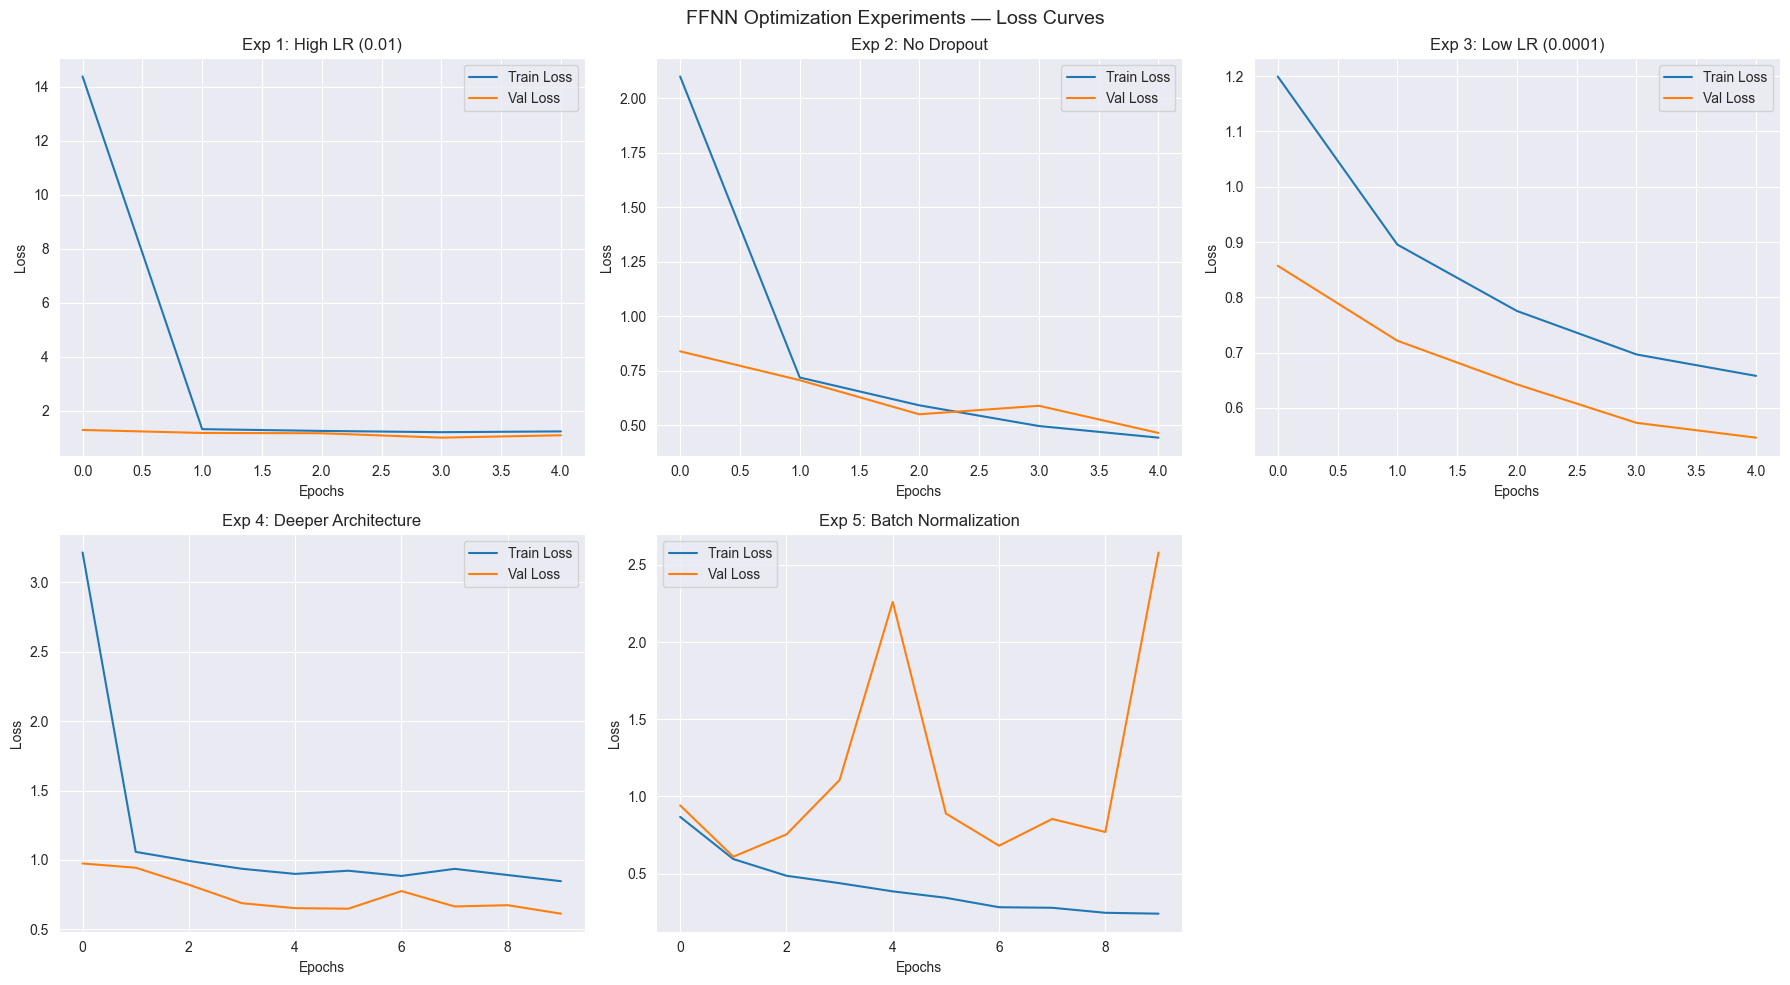

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

experiments = [
    (history_ffnn_exp1, "Exp 1: High LR (0.01)"),
    (history_ffnn_exp2, "Exp 2: No Dropout"),
    (history_ffnn_exp3, "Exp 3: Low LR (0.0001)"),
    (history_ffnn_exp4, "Exp 4: Deeper Architecture"),
    (history_ffnn_exp5, "Exp 5: Batch Normalization"),
]

for i, (hist, title) in enumerate(experiments):
    axes[i].plot(hist.history['loss'], label='Train Loss')
    axes[i].plot(hist.history['val_loss'], label='Val Loss')
    axes[i].set_title(title)
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Loss")
    axes[i].legend()

axes[-1].axis('off')  # hide the empty 6th subplot

plt.suptitle("FFNN Optimization Experiments — Loss Curves", fontsize=14)
plt.tight_layout()
plt.show()

### FFNN Experiments — Validation Accuracy Comparison

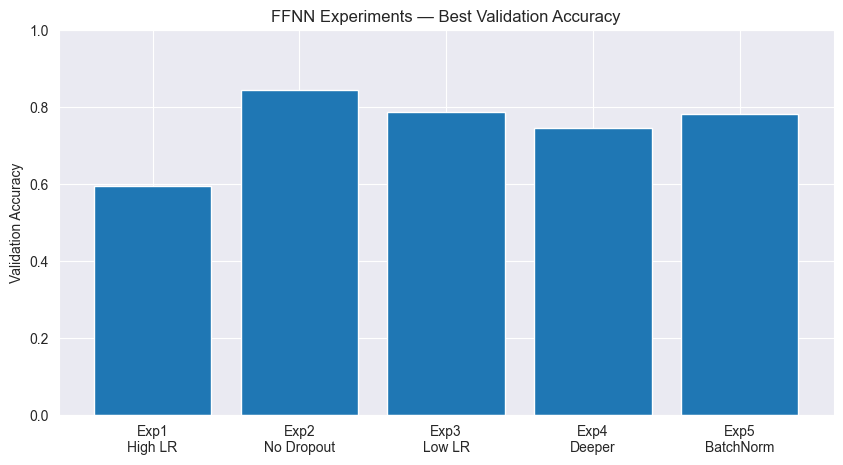

In [36]:
val_accs = [
    max(history_ffnn_exp1.history['val_accuracy']),
    max(history_ffnn_exp2.history['val_accuracy']),
    max(history_ffnn_exp3.history['val_accuracy']),
    max(history_ffnn_exp4.history['val_accuracy']),
    max(history_ffnn_exp5.history['val_accuracy']),
]

exp_labels = [
    "Exp1\nHigh LR",
    "Exp2\nNo Dropout",
    "Exp3\nLow LR",
    "Exp4\nDeeper",
    "Exp5\nBatchNorm",
]

plt.figure(figsize=(10, 5))
plt.bar(exp_labels, val_accs)
plt.title("FFNN Experiments — Best Validation Accuracy")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.show()

### These experiments demonstrate how hyperparameter choices and architecture
### decisions significantly impact FFNN performance on image classification tasks.